Filename: /Users/users/wroosterhof/PROGNUM-repo/Task6/ngc6946.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU     205   (100, 100, 101)   float32   


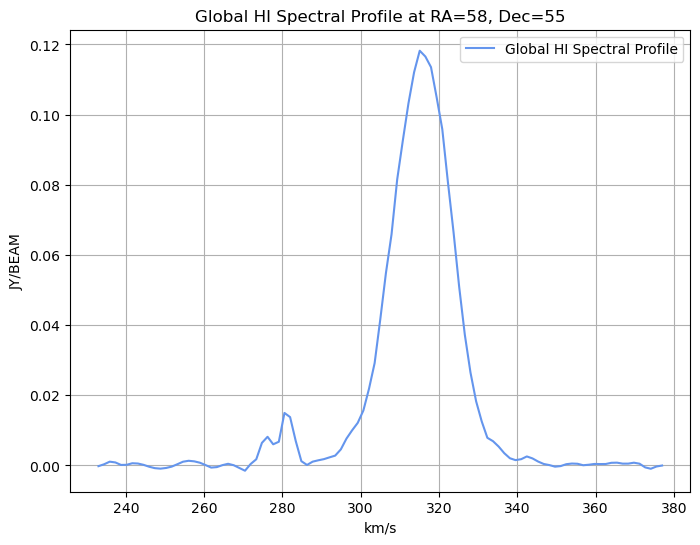

TypeError: Cannot cast array data from dtype('O') to dtype('float64') according to the rule 'safe'

error: Result from function call is not a proper array of floats.

In [8]:
import numpy as np
from matplotlib import pyplot as plt
from astropy.io import fits
import sympy as sp

#Importing the fits file.
hdulist = fits.open('~/PROGNUM-repo/Task6/ngc6946.fits')
dat = hdulist[0].data
hdulist.info()
hdr = hdulist[0].header

profile1 = dat[:,55,58] #Slicing the data for given specifications.
profile = np.array(profile1, dtype = float)
v_start = 233
v_end = 377
velocity = np.linspace(v_start, v_end, len(profile), dtype = float)

#Plotting global HI spectral profile.
fig = plt.figure(figsize = (8,6))
frame = fig.add_subplot(1,1,1)
plt.plot(velocity, profile, color = "cornflowerblue", label = "Global HI Spectral Profile")
frame.set_xlabel(hdr["CUNIT3"])
frame.set_ylabel(hdr["BUNIT"])
frame.set_title("Global HI Spectral Profile at RA=58, Dec=55")
frame.legend()
frame.grid()
plt.show()


def f_sp(x, amp, mu, sigma, zero):
    return amp * sp.exp(-((x - mu)**2) / (2 * sigma**2)) + zero
    
def f_np(x, amp, mu, sigma, zero):
    return amp * np.exp(-((x - mu)**2) / (2 * sigma**2)) + zero

"""x, amp, mu, sigma, zero = sp.symbols('x amp mu sigma zero')

func = f(x, amp, mu, sigma, zero)

# Calculate derivatives with respect to the parameters
diff_amp = sp.diff(func, amp)
diff_mu = sp.diff(func, mu)
diff_sigma = sp.diff(func, sigma)

print(f"Derivative w.r.t. amplitude: {diff_amp}")
print(f"The derivatice w.r.t. the amplitude does not have another term of amplitude anymore, and therefore is liner.")
print(f"\nDerivative w.r.t. mu: {diff_mu}")
print(f"The derivative w.r.t. mu does have another term of mu, meaning it's non-linear.")
print(f"\nDerivative w.r.t. sigma: {diff_sigma}")
print(f"The derivative w.r.t. sigma does have another term of sigma, meaning it's non-linear.")
print(f"\nSince both mu and sigma lead to a non-linear outcome, the whole function of f is non-linear.")"""

def estimates(x_data, y_data):
    est_zero = np.min(y_data) #"zero" is the measurement for the noise, so when we take the minimum value, we get the closest to the noise value.
    max_idx = np.argmax(y_data)
    est_mu = x_data[max_idx]
    est_amp = np.max(y_data-est_zero) #Amplitude is the value above the baseline. This base line is the zero, for the background, so you take the peak - the baseline.
    est_sigma = (np.max(x_data) - np.min(x_data))/10 #max(x)-min(x) so that even if the data is not sorted on x, it still takes the highest x (often time or wavelength) - the lowest x. Division by 10 since that's an estimate that 1/10th of the picture is the peak.
    return [est_amp, est_mu, est_sigma, est_zero]

from matplotlib import pyplot as plt
from scipy.optimize import curve_fit

mask = np.isfinite(v_clean) & np.isfinite(p_clean)
v_clean = v_clean[mask]
p_clean = p_clean[mask]

# 4. Perform the Fit
est_values = estimates(v_clean, p_clean)
p0_list = [float(x) for x in est_values]
popt, pcov = curve_fit(f, v_clean, p_clean, p0=p0_list)
perr = np.sqrt(np.diag(pcov))

# 5. Plotting
v_fine = np.linspace(v_clean.min(), v_clean.max(), 500)
profile_fit = f(v_fine, *popt)

plt.figure(figsize=(8, 6))
plt.plot(v_clean, p_clean, 'o', markersize=3, color="cornflowerblue", label="Data")
plt.plot(v_fine, profile_fit, color="red", lw=2, label="Gaussian Fit")
plt.xlabel(hdr["CUNIT3"])
plt.ylabel(hdr["BUNIT"])
plt.title(f"Gaussian Fit: $\mu$={popt[1]:.1f}, $\sigma$={popt[2]:.1f}")
plt.legend()
plt.show()